# GRUPPUPPGIFT - DEEP LEARNING - GRUPP5

## 1. Data förtåelse & preprocessing


#### Importer bibliotek


In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

#### Ladda in Fashion MNIST drikt från keras

In [14]:
# Ladda datasetet från Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Visa grundläggande information om datasetet
print("====Grundläggande information om datasetet====")
print(f"Träningsbilder: {x_train.shape} (bilder, höjd, bredd)")
print(f"Träningsetiketter: {y_train.shape}")
print(f"Testbilder: {x_test.shape}")
print(f"Testetiketter: {y_test.shape}")
print(f"Antal klasser: {len(np.unique(y_train))}")
print("Pixelvärdesintervall:", x_train.min(), "-", x_train.max())

====Grundläggande information om datasetet====
Träningsbilder: (60000, 28, 28) (bilder, höjd, bredd)
Träningsetiketter: (60000,)
Testbilder: (10000, 28, 28)
Testetiketter: (10000,)
Antal klasser: 10
Pixelvärdesintervall: 0 - 255


#### Undersök klasser och balans


==== Klassfördelning i träningssetet:====
0: T-shirt/top     - 6000 bilder
1: Trouser         - 6000 bilder
2: Pullover        - 6000 bilder
3: Dress           - 6000 bilder
4: Coat            - 6000 bilder
5: Sandal          - 6000 bilder
6: Shirt           - 6000 bilder
7: Sneaker         - 6000 bilder
8: Bag             - 6000 bilder
9: Ankle boot      - 6000 bilder


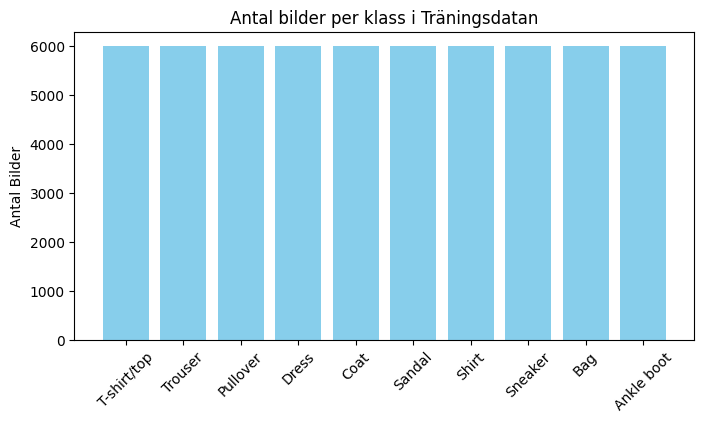

In [15]:
# Klassnamn ( enligt Fashion MNIST namnsättning)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

# Undersök klassbalans - räkna antal bilder per klass i träningssetet
unique, counts = np.unique(y_train, return_counts=True)

print("\n==== Klassfördelning i träningssetet:====")
for i, (name, cnt) in enumerate(zip(class_names, counts)):
    print(f"{i}: {name:15} - {cnt} bilder")

# Visualisera några exempelbilder från varje klass
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Antal bilder per klass i Träningsdatan")
plt.ylabel("Antal Bilder")
plt.show()

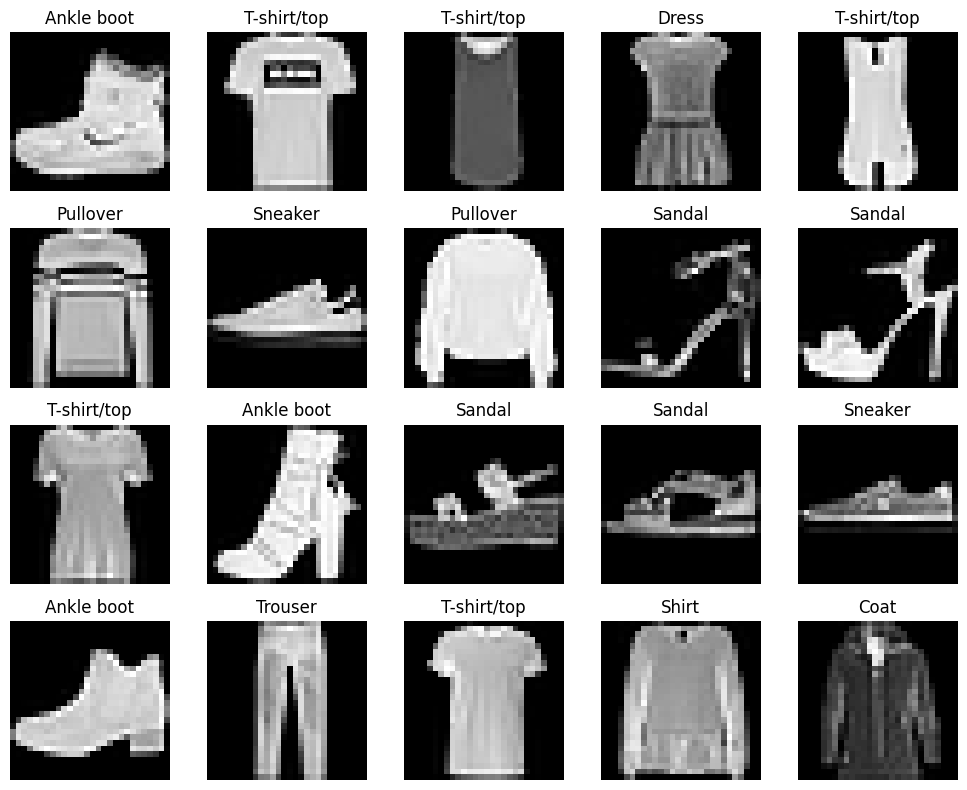

In [16]:
# Visa exempelbilder från varje klass
plt.figure(figsize=(10,8))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Normalisera pixelvärdena till intervallet [0, 1]

In [17]:
# Normalisera pixelvärdena till intervallet [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"\nEfter normalisering - pixelvärden mellan {x_train.min():.2f} och {x_train.max():.2f}")



Efter normalisering - pixelvärden mellan 0.00 och 1.00


### Anpassa input shape för CNN
CNN-lager i Keras kräver en kanaldimension - även för gråskalebilder.

In [18]:
# Lägg till en dimension för kanaler (gråskala) så att datan blir (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Ny shape för träningsdata: {x_train.shape} (bilder, höjd, bredd, kanaler)")
print(f"Ny shape för testdata: {x_test.shape}")

Ny shape för träningsdata: (60000, 28, 28, 1) (bilder, höjd, bredd, kanaler)
Ny shape för testdata: (10000, 28, 28, 1)


## Sammanfattning för del1:
Sammanfattning av data förståelse och & preprocessing.
- Dataset: Fashion MNIST
- 60 000 träningsbilder, 10 000 testbilder
- Bildstorlek: 28x20 pixlar, gråskala
- Efter normalisering - pixelvärden mellan 0.00 och 1.00
- Input shape redo för CNN: (28, 28, 1)
- Inga saknade värden eller konstigheter
- Data är nu klar för att användas i modell